<a href="https://colab.research.google.com/github/rithishdev/DL_Lab/blob/main/DL_Exp01_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8022 - loss: 0.5398 - val_accuracy: 0.9451 - val_loss: 0.3986
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9313 - loss: 0.3052 - val_accuracy: 0.9560 - val_loss: 0.2457
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9451 - loss: 0.1987 - val_accuracy: 0.9670 - val_loss: 0.1695
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9615 - loss: 0.1455 - val_accuracy: 0.9670 - val_loss: 0.1308
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9698 - loss: 0.1155 - val_accuracy: 0.9670 - val_loss: 0.1087
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0976 - val_accuracy: 0.9670 - val_loss: 0.0933
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9808 - loss: 0.0847 - val_accuracy: 0.9780 - val_loss: 0.0840
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.0766 - val_accuracy: 0.9780 - val_loss: 0.0769
Ep

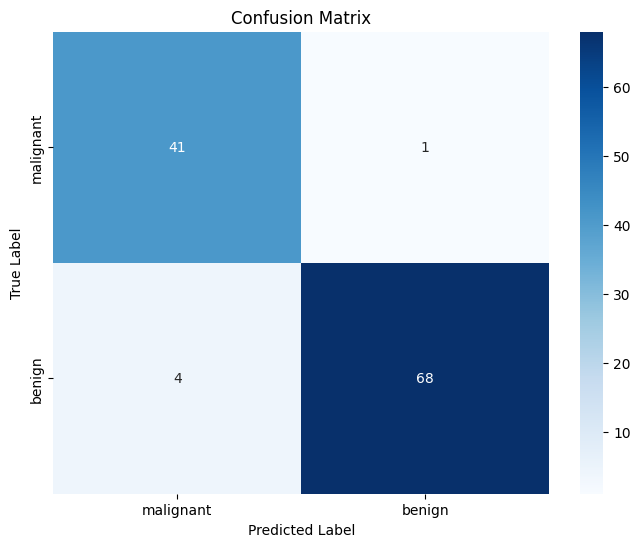

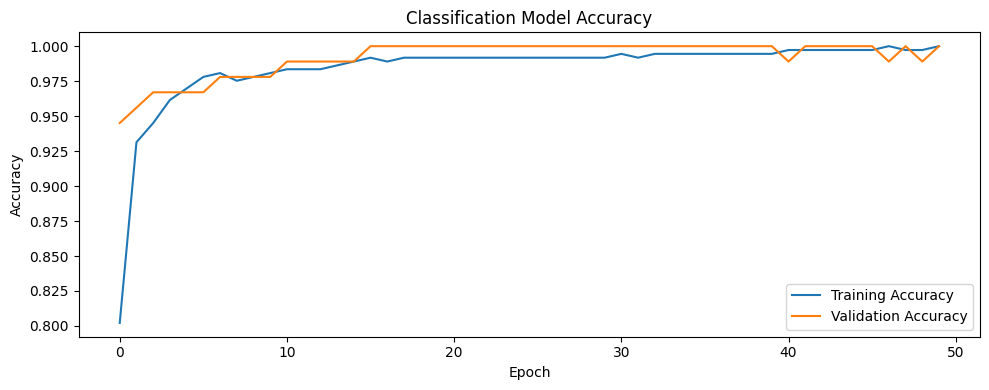

In [3]:
#Part B - ANN FOR CLASSIFICATION
#Dataset - Breast cancer dataset
#24BAD099 - Rithish A

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns # Added seaborn import

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load dataset
cancer = load_breast_cancer()
X_cls = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cls = cancer.target

# Split dataset
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Feature scaling
scaler_cls = StandardScaler()
X_train_c = scaler_cls.fit_transform(X_train_c)
X_test_c = scaler_cls.transform(X_test_c)

# Build ANN model
classification_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train_c.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile model
classification_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
classification_history = classification_model.fit(
    X_train_c,
    y_train_c,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# Predict and evaluate
probabilities = classification_model.predict(X_test_c).ravel()
y_pred_c = (probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
cm = confusion_matrix(y_test_c, y_pred_c)

print("\nClassification Evaluation")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))

# Confusion Matrix Chart
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Optional training curves
plt.figure(figsize=(10, 4))
plt.plot(classification_history.history["accuracy"], label="Training Accuracy")
plt.plot(classification_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Classification Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()